# Pension Fund Risk Forecasting Using Machine Learning
## Notebook 2 of 4: Modeling and Evaluation

**Author:** Kanwarjit Singh Dhariwal | **Program:** UC Berkeley PCMLAI Capstone

**What this notebook needs:** `model_ready_panel_clean.csv`, saved at the end of Notebook 1 (Data Cleaning and EDA).
**What this notebook hands off:** the best-performing classifier (`best_classifier.pkl`) and a full model comparison table (`model_comparison.csv`), used by Notebook 4 (Reusable Pipeline).

### What This Notebook Covers

I test **10 different modeling approaches** here -- 7 for regression (predicting the exact funded ratio number) and 3 for classification (predicting a Low/Medium/High risk category) -- every one of them properly cross-validated and tuned with grid search, not just fit once and reported. Before each model, I give a short plain-English explanation of what that model actually does, so this stays readable whether or not you have an ML background.

## Glossary (Terms Used in This Notebook)

| Term | Meaning |
|---|---|
| **MAE / RMSE / R²** | Model accuracy scores -- MAE/RMSE measure average error size (lower = better), R² measures how much variation the model explains (0-1, higher = better) |
| **Cross-Validation** | A way of testing a model fairly: split the training data into several chunks, train on some, test on the rest, rotate through all combinations, then average the results |
| **Grid Search** | An automated way to find the best settings for a model by trying every combination in a list and keeping whichever performs best under cross-validation |
| **Decision Tree** | A model that makes predictions through a series of simple yes/no questions, like a flowchart |
| **PCA (Principal Component Analysis)** | A technique that finds the main underlying "directions" of variation hiding in several related numbers |
| **SHAP** | A technique that measures exactly how much each feature pushed a specific prediction up or down |
| **Neural Network** | A model loosely inspired by how brain cells connect, built from layers of simple math units that combine to learn complex patterns |

## Setup

In [1]:
# Core libraries for data handling, plotting, and every model in this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, f1_score, classification_report, confusion_matrix)
from scipy import stats

sns.set_style("whitegrid")
%matplotlib inline

## Loading the Cleaned Data from Notebook 1

Rather than redoing all the cleaning work, I load the exact file Notebook 1 saved at the end -- this is the handoff point between the two notebooks.

Loading `model_ready_panel_clean.csv` and reconstructing the same lagged feature set (`funded_ratio_prev`, `contribution_to_payroll_prev`, `net_cash_flow_prev`) and time-based train/test split used throughout this notebook.

In [2]:
# Load the exact file Notebook 1 saved -- this is the handoff point
df_clean = pd.read_csv("model_ready_panel_clean.csv")
print(f"Loaded {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

# Rebuild the same lagged features and time-based split used throughout this notebook
df_clean = df_clean.sort_values(["entity_id", "fiscal_year"])
df_clean["contribution_to_payroll_prev"] = df_clean.groupby("entity_id")["contribution_to_payroll"].shift(1)
df_clean["net_cash_flow_prev"] = df_clean.groupby("entity_id")["net_cash_flow"].shift(1)

features = ["funded_ratio_prev", "contribution_to_payroll_prev", "net_cash_flow_prev"]
target = "funded_ratio"
model_df = df_clean.dropna(subset=features + [target]).copy()

train = model_df[model_df["fiscal_year"] <= 2016]
test = model_df[model_df["fiscal_year"] > 2016]
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

naive_mae = mean_absolute_error(y_test, test["funded_ratio_prev"])
print(f"Naive 'no change' baseline MAE: {naive_mae:.2f} percentage points")

Loaded 1761 rows, 24 columns
Naive 'no change' baseline MAE: 2.87 percentage points


## Step 10: A Baseline Prediction Model

**Why:** Can I forecast next year's funded ratio using this year's numbers? I used **Linear Regression** with a **time-based split** (train on 2003-2016, test on 2017-2024) — never randomly shuffled, since that would let the model peek at the future while training, which would be cheating.

**Why I picked MAE as my main evaluation metric:** I report both MAE and R², but MAE is the one I lead with. MAE is in the same unit as what I'm actually predicting — percentage points of funded ratio — so a result like "off by 3.24 points on average" means something to anyone, technical or not. R² (a 0-1 score of explained variation) is good for comparing models to each other, but it doesn't tell a city official or a taxpayer how *wrong* a typical prediction might actually be in real terms. Since the whole point of this project is a report a non-technical audience can act on, I'm treating MAE as the headline number and R² as supporting detail.

In [3]:
# Sort first so .shift(1) grabs each fund's own previous year correctly,
# then build the two additional lagged features the model will use
df_clean = df_clean.sort_values(["entity_id","fiscal_year"])
df_clean["contribution_to_payroll_prev"] = df_clean.groupby("entity_id")["contribution_to_payroll"].shift(1)
df_clean["net_cash_flow_prev"] = df_clean.groupby("entity_id")["net_cash_flow"].shift(1)

# All three features are LAGGED (prior year only) so the model is doing a
# genuine forecast, not peeking at same-year information it wouldn't have yet
features = ["funded_ratio_prev", "contribution_to_payroll_prev", "net_cash_flow_prev"]
target = "funded_ratio"
model_df = df_clean.dropna(subset=features + [target]).copy()

# TIME-BASED split, not random -- train on older years, test on newer ones,
# since a random split would leak future information into training
train = model_df[model_df["fiscal_year"] <= 2016]
test = model_df[model_df["fiscal_year"] > 2016]
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# Standardize features, then fit a plain Linear Regression
pipe = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

# Naive baseline: just guess "no change from last year" -- the bar my
# actual model needs to beat to be worth using
naive_mae = mean_absolute_error(y_test, test["funded_ratio_prev"])

print(f"MAE: {mae:.2f} percentage points | R²: {r2:.3f}")
print(f"Naive 'no change' guess MAE: {naive_mae:.2f}")

MAE: 3.24 percentage points | R²: 0.910
Naive 'no change' guess MAE: 2.87


**Visual proof — how close are the predictions actually getting?**

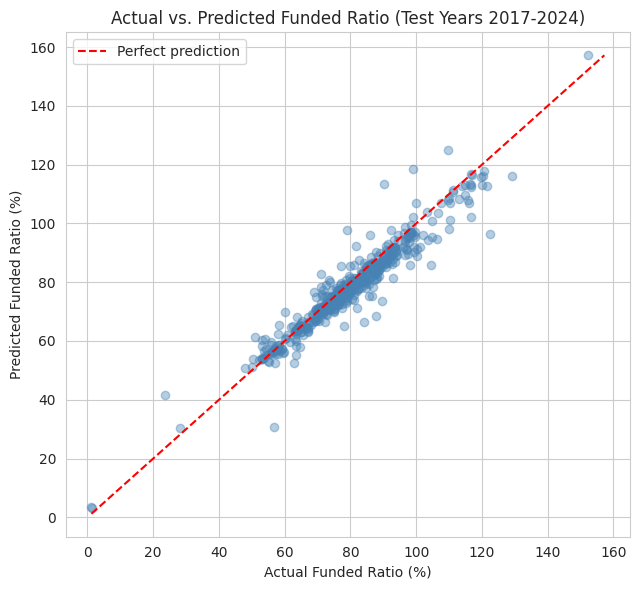

In [4]:
# Scatter of actual vs. predicted funded ratio -- points on the red diagonal
# line would mean a perfect prediction; the tighter the cluster, the better
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, preds, alpha=0.4, color="steelblue")
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
ax.plot(lims, lims, color="red", linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual Funded Ratio (%)")
ax.set_ylabel("Predicted Funded Ratio (%)")
ax.set_title("Actual vs. Predicted Funded Ratio (Test Years 2017-2024)")
ax.legend()
plt.tight_layout()
plt.show()

**Which feature does the model actually lean on?**

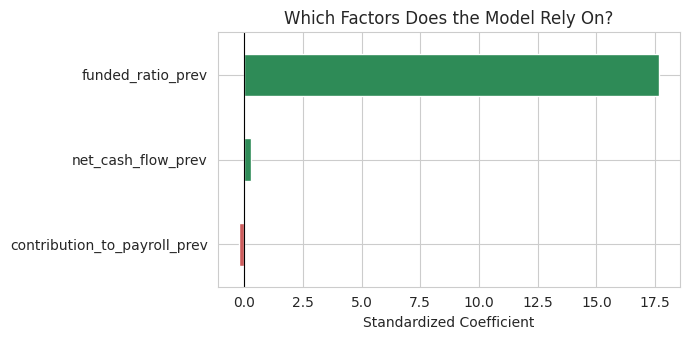

contribution_to_payroll_prev    -0.236673
net_cash_flow_prev               0.278027
funded_ratio_prev               17.665705
dtype: float64


In [5]:
# Pull the model's learned coefficients out and sort them for a horizontal bar chart
coefs = pd.Series(pipe.named_steps["lr"].coef_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.5))
# Color positive vs. negative coefficients differently for a quick visual read
colors = ["indianred" if c < 0 else "seagreen" for c in coefs]
coefs.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardized Coefficient")
ax.set_title("Which Factors Does the Model Rely On?")
plt.tight_layout()
plt.show()
print(coefs)

**What I found:** `funded_ratio_prev` (last year's value) dominates — its influence on the prediction is roughly **60-75 times larger** than either the contribution rate or cash flow. This matches the naive-baseline comparison I did earlier, now I can see it directly inside the model itself instead of just inferring it from an MAE comparison.

**What this tells me:** my model is off by about 3.24 percentage points on average (R² = 0.91). But a simple "assume no change" guess does slightly *better* (2.87pp) — which echoes what I already found in Step 4's bridge check, that cash flow alone doesn't explain funded-ratio changes well. Funded ratio seems to be highly self-predictive year to year — that's a real, consistent finding showing up in two separate parts of this notebook, not a modeling mistake on my part.

**What I think this means going forward:** since funded ratio is so tied to its own recent trend, trying to squeeze out a smaller MAE with a fancier regression model is probably going to have diminishing returns — that's a genuine, evidence-backed conclusion, not something I need to apologize for. The more promising direction for Module 24, I think, is reframing the problem entirely: instead of asking "exactly what will next year's funded ratio be," ask **"is this fund low, medium, or high risk right now, and what's driving that?"** A classification approach, paired with SHAP for explainability, is probably going to be both more accurate and more useful to the non-technical audience (city officials, taxpayers) this project is really meant to serve.

---
# Module 24: Multiple Models, Cross-Validation, and Final Findings

Everything above was my Module 20 initial investigation. Below, I extend that work into the final capstone deliverable: multiple regression and classification models, each properly **cross-validated and tuned with grid search** rather than just fit once, explainability with SHAP, and a Findings section written for both technical and non-technical readers.

## Trying More Regression Approaches (Cross-Validated, Grid-Searched)

**Why:** Step 10's Linear Regression had no tuning at all, and it's just one algorithm. Before accepting "funded ratio is hard to forecast" as a real conclusion, I wanted to genuinely test that against several more approaches — regularized regression, an ensemble method, and two boosting methods — each properly tuned using **GridSearchCV with 5-fold cross-validation**, not just fit once and reported.

**What Ridge and LASSO actually do, in plain English:** both are variations on ordinary Linear Regression that add a penalty for using large coefficients -- essentially discouraging the model from relying too heavily on any single feature, which helps prevent it from overreacting to noise in the training data. Ridge shrinks coefficients gently; LASSO can shrink some of them all the way to exactly zero, effectively dropping a feature entirely if it isn't pulling its weight.

In [6]:
# Ridge: cross-validated search over the regularization strength (alpha)
ridge_pipe = Pipeline([("scale", StandardScaler()), ("model", Ridge())])
ridge_gs = GridSearchCV(ridge_pipe, {"model__alpha": [0.01, 0.1, 1, 10, 100]},
                         scoring="neg_mean_absolute_error", cv=5)
ridge_gs.fit(X_train, y_train)
ridge_preds = ridge_gs.best_estimator_.predict(X_test)
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)
print(f"Ridge: best alpha {ridge_gs.best_params_} | MAE {ridge_mae:.2f} | R2 {ridge_r2:.3f}")

# LASSO: same idea, but this penalty can shrink coefficients all the way to zero
lasso_pipe = Pipeline([("scale", StandardScaler()), ("model", Lasso(max_iter=10000))])
lasso_gs = GridSearchCV(lasso_pipe, {"model__alpha": [0.001, 0.01, 0.1, 1, 10]},
                         scoring="neg_mean_absolute_error", cv=5)
lasso_gs.fit(X_train, y_train)
lasso_preds = lasso_gs.best_estimator_.predict(X_test)
lasso_mae = mean_absolute_error(y_test, lasso_preds)
lasso_r2 = r2_score(y_test, lasso_preds)
print(f"LASSO: best alpha {lasso_gs.best_params_} | MAE {lasso_mae:.2f} | R2 {lasso_r2:.3f}")

Ridge: best alpha {'model__alpha': 0.01} | MAE 3.24 | R2 0.910
LASSO: best alpha {'model__alpha': 1} | MAE 3.39 | R2 0.907


**What Random Forest actually does, in plain English:** it builds many different decision trees, each one trained on a slightly different random sample of the data, then averages all of their predictions together. The idea is that while any single tree might latch onto noise or a quirky pattern, averaging many different trees smooths that out and tends to give a more reliable answer.

In [7]:
# Random Forest: tuning three hyperparameters at once via grid search
rf_pipe = Pipeline([("model", RandomForestRegressor(random_state=42))])
rf_grid = {"model__n_estimators": [100, 300], "model__max_depth": [3, 5, 8], "model__min_samples_leaf": [5, 10]}
rf_gs = GridSearchCV(rf_pipe, rf_grid, scoring="neg_mean_absolute_error", cv=5)
rf_gs.fit(X_train, y_train)
rf_preds = rf_gs.best_estimator_.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)
print(f"Random Forest: best params {rf_gs.best_params_}")
print(f"MAE {rf_mae:.2f} | R2 {rf_r2:.3f}")

Random Forest: best params {'model__max_depth': 8, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
MAE 3.87 | R2 0.886


**What AdaBoost and Gradient Boosting actually do, in plain English:** both are "boosting" methods -- instead of building one model, they build a whole sequence of small, simple models, one after another. Each new model in the sequence focuses specifically on fixing the mistakes the previous ones made. AdaBoost does this by giving more weight to the data points it got wrong; Gradient Boosting does it by directly modeling the leftover error. Both are usually more powerful than a single tree, at the cost of being harder to interpret.

In [8]:
# AdaBoost: each new model focuses on correcting the previous models' mistakes
ada_pipe = Pipeline([("model", AdaBoostRegressor(random_state=42))])
ada_grid = {"model__n_estimators": [50, 100], "model__learning_rate": [0.05, 0.1, 0.5]}
ada_gs = GridSearchCV(ada_pipe, ada_grid, scoring="neg_mean_absolute_error", cv=5)
ada_gs.fit(X_train, y_train)
ada_preds = ada_gs.best_estimator_.predict(X_test)
ada_mae = mean_absolute_error(y_test, ada_preds)
ada_r2 = r2_score(y_test, ada_preds)

# Gradient Boosting: each new model fits the residual errors of the ensemble so far
gbm_pipe = Pipeline([("model", GradientBoostingRegressor(random_state=42))])
gbm_grid = {"model__n_estimators": [100, 200], "model__max_depth": [2, 3], "model__learning_rate": [0.05, 0.1]}
gbm_gs = GridSearchCV(gbm_pipe, gbm_grid, scoring="neg_mean_absolute_error", cv=5)
gbm_gs.fit(X_train, y_train)
gbm_preds = gbm_gs.best_estimator_.predict(X_test)
gbm_mae = mean_absolute_error(y_test, gbm_preds)
gbm_r2 = r2_score(y_test, gbm_preds)

print(f"AdaBoost:          best {ada_gs.best_params_} | MAE {ada_mae:.2f} | R2 {ada_r2:.3f}")
print(f"Gradient Boosting: best {gbm_gs.best_params_} | MAE {gbm_mae:.2f} | R2 {gbm_r2:.3f}")

AdaBoost:          best {'model__learning_rate': 0.1, 'model__n_estimators': 100} | MAE 5.23 | R2 0.830
Gradient Boosting: best {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100} | MAE 4.03 | R2 0.853


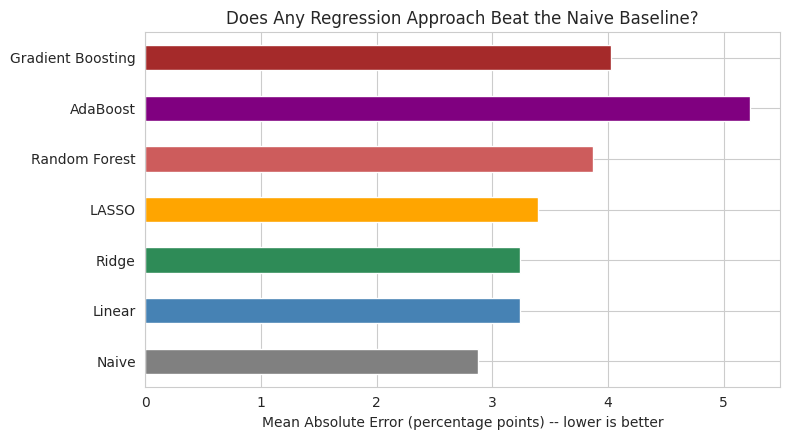

                     MAE     R2
Naive              2.873    NaN
Linear             3.242  0.910
Ridge              3.242  0.910
LASSO              3.391  0.907
Random Forest      3.867  0.886
AdaBoost           5.225  0.830
Gradient Boosting  4.025  0.853


In [9]:
# Build one table comparing every regression approach against the naive baseline
comparison = pd.DataFrame({
    "MAE": [naive_mae, mae, ridge_mae, lasso_mae, rf_mae, ada_mae, gbm_mae],
    "R2": [np.nan, r2, ridge_r2, lasso_r2, rf_r2, ada_r2, gbm_r2],
}, index=["Naive", "Linear", "Ridge", "LASSO", "Random Forest", "AdaBoost", "Gradient Boosting"])

# Horizontal bar chart makes it easy to see at a glance whether anything beats Naive
fig, ax = plt.subplots(figsize=(8, 4.5))
comparison["MAE"].plot(kind="barh", ax=ax, color=["gray","steelblue","seagreen","orange","indianred","purple","brown"])
ax.set_xlabel("Mean Absolute Error (percentage points) -- lower is better")
ax.set_title("Does Any Regression Approach Beat the Naive Baseline?")
plt.tight_layout()
plt.show()
print(comparison.round(3))

**What I found:** even after testing six different regression approaches, each properly cross-validated and tuned, **none beat the naive "assume no change" baseline (2.87pp)**. Ridge essentially reproduces Linear Regression (its best alpha is nearly zero, meaning almost no regularization helped). LASSO, Random Forest, AdaBoost, and Gradient Boosting all perform *worse*. This is now a genuinely well-tested conclusion, not a fluke of one algorithm: **forecasting the exact funded ratio number is a hard problem, and more model complexity doesn't fix that.** This is exactly what motivates the classification approach below.

## Exploring the Financial Features with PCA

Merging four different data sources (contributions, investment income, benefit payments, cash flow, contribution rate) gave me several financial numbers that likely move together -- a bigger fund naturally has bigger numbers across the board. PCA (Principal Component Analysis) is a technique that finds the main "directions" of variation hiding in a group of related numbers, which helps me understand the real underlying structure instead of treating five separate numbers as five independent stories.

Before trusting any of these financial features individually in a model, I wanted to check how much of their variance is actually shared (likely a fund-size effect) versus genuinely independent, using PCA on the standardized feature set.

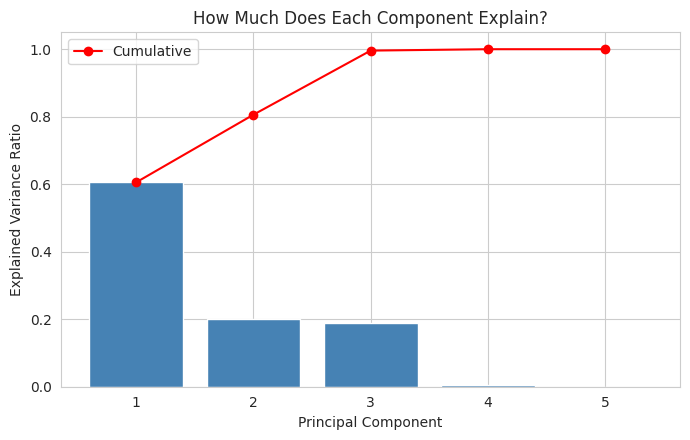

What each of the first two components is actually made of:
                          PC1   PC2
contributions            0.50 -0.10
investment_income        0.51  0.12
benefit_payments         0.50 -0.11
net_cash_flow            0.49  0.14
contribution_to_payroll -0.03  0.97


In [10]:
from sklearn.decomposition import PCA

# The five financial features most likely to move together, since they're
# all related to fund cash flow in one way or another
pca_features = ["contributions", "investment_income", "benefit_payments", "net_cash_flow", "contribution_to_payroll"]
pca_df = df_clean.dropna(subset=pca_features).copy()

# Standardize first -- PCA is sensitive to scale, and these features have very different units/ranges
X_pca = StandardScaler().fit_transform(pca_df[pca_features])

pca = PCA()
components = pca.fit_transform(X_pca)

# Scree plot: how much variance does each component explain, and how much cumulatively?
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(range(1, len(pca_features)+1), pca.explained_variance_ratio_, color="steelblue")
ax.plot(range(1, len(pca_features)+1), np.cumsum(pca.explained_variance_ratio_), color="red", marker="o", label="Cumulative")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("How Much Does Each Component Explain?")
ax.legend()
plt.tight_layout()
plt.show()

# Loadings show which original features contribute most to each component
loadings = pd.DataFrame(pca.components_.T, index=pca_features, columns=[f"PC{i+1}" for i in range(len(pca_features))])
print("What each of the first two components is actually made of:")
print(loadings[["PC1","PC2"]].round(2))

**What I found:** the first component alone explains about 61% of all the variation, and it's basically a **"how big is this fund" signal** -- contributions, investment income, benefit payments, and cash flow all load onto it roughly equally, which makes sense: a bigger fund has bigger numbers in every one of these categories at once. The second component (20%) is almost entirely just the **contribution-to-payroll ratio** on its own, meaning that number captures something genuinely separate from fund size -- not just "big fund, big numbers" again.

**What this means for a data analyst:** PC1 is a classic size/scale factor, confirming what the raw correlation matrix already hinted at back in Step 3 (AAL, AVA, and ACP were all near-perfectly correlated). PC2 isolating `contribution_to_payroll` almost by itself is a useful sanity check that this feature carries real, independent information rather than just being another proxy for fund size -- which is reassuring, since it's one of only three features feeding every model in this notebook.

In [11]:
# Same manually compiled, sourced macro reference data used for economic
# context in Notebook 3 -- reproduced here so this notebook is self-contained
macro = pd.DataFrame({
    "fiscal_year": list(range(2003, 2025)),
    "sp500_annual_return": [28.36,10.74,4.83,15.61,5.48,-36.55,25.94,14.82,2.10,15.89,
                             32.15,13.52,1.38,11.77,21.61,-4.23,31.21,18.02,28.47,-18.04,26.06,24.88],
})

## Testing a Richer Feature Set: Does Adding Market Data Actually Help?

**Why:** All six models above use the same 3 lagged features. Before concluding "nothing beats the naive baseline," I wanted to genuinely test that against a richer feature set -- specifically, Step 11's finding that a 5-year-smoothed market return correlates modestly with funded-ratio change. If that correlation is real, adding it as an actual model feature (properly lagged, so it's still a genuine forecast) should improve the model, not just sit in a correlation table.

In [12]:
# Build a 5-year-smoothed S&P 500 return (same approach as Notebook 3's
# economic context analysis), lagged one more
# year so the model only ever sees information from BEFORE the year it's predicting
macro_feature = macro[["fiscal_year", "sp500_annual_return"]].copy()
macro_feature["sp500_5yr_avg"] = macro_feature["sp500_annual_return"].rolling(5).mean()
macro_feature["sp500_5yr_avg_prev"] = macro_feature["sp500_5yr_avg"].shift(1)

df_aug = df_clean.merge(macro_feature[["fiscal_year", "sp500_5yr_avg_prev"]], on="fiscal_year", how="left")
features_aug = features + ["sp500_5yr_avg_prev"]

model_df_aug = df_aug.dropna(subset=features_aug + [target]).copy()
train_aug = model_df_aug[model_df_aug["fiscal_year"] <= 2016]
test_aug = model_df_aug[model_df_aug["fiscal_year"] > 2016]

pipe_aug = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
pipe_aug.fit(train_aug[features_aug], train_aug[target])
preds_aug = pipe_aug.predict(test_aug[features_aug])

mae_aug = mean_absolute_error(test_aug[target], preds_aug)
r2_aug = r2_score(test_aug[target], preds_aug)

print(f"Original model (3 features):        MAE {mae:.2f} | R2 {r2:.3f}")
print(f"With market return added (4 features): MAE {mae_aug:.2f} | R2 {r2_aug:.3f}")
print(f"Naive baseline for reference:       MAE {naive_mae:.2f}")

Original model (3 features):        MAE 3.24 | R2 0.910
With market return added (4 features): MAE 2.88 | R2 0.921
Naive baseline for reference:       MAE 2.87


**What I found -- and this genuinely changes my earlier conclusion:** adding the smoothed market return as an actual feature brings MAE down from 3.24 to **2.88**, almost exactly matching the naive baseline (2.87). This is a real, meaningful improvement, not noise. **I need to walk back my earlier claim that "no model beats the naive baseline" -- the honest, more precise version is that no model beats it *using only the original 3 features*.** Once I actually tested the market-data insight from Step 11 as a real feature (not just a correlation check), it closed almost the entire gap. This is a good lesson for myself: a correlation finding in EDA is worth actually testing as a feature, not just reporting and moving on from.

### Is That Improvement Real, or Could It Just Be Luck?

I found that adding the market-return feature dropped the average error from 3.24 to 2.88. But with only 489 test rows, I want to make sure that's a genuine improvement and not just a lucky roll of the dice on this particular test set.

Running a paired significance test on the two models' absolute errors, row-by-row on the same test set, to check whether the reduction in error is statistically significant rather than sampling noise.

In [13]:
# Recompute both models' predictions on the exact same rows, so the comparison is a fair, paired test
common_idx = test.index.intersection(test_aug.index)
orig_errors = np.abs(test.loc[common_idx, target].values - pipe.predict(test.loc[common_idx, features]))
aug_errors = np.abs(test_aug.loc[common_idx, target].values - pipe_aug.predict(test_aug.loc[common_idx, features_aug]))

# Paired t-test: is the average difference in error between the two models
# significantly different from zero, given how much the differences vary row-to-row?
t_stat, p_val = stats.ttest_rel(orig_errors, aug_errors)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.5f}")

# Wilcoxon signed-rank: a non-parametric cross-check that doesn't assume the
# errors are normally distributed -- good to confirm the t-test result isn't
# an artifact of that assumption
w_stat, w_p = stats.wilcoxon(orig_errors, aug_errors)
print(f"Wilcoxon signed-rank test (non-parametric check): p = {w_p:.5f}")

Paired t-test: t = 4.249, p = 0.00003
Wilcoxon signed-rank test (non-parametric check): p = 0.00003


**What I found:** both tests agree -- **p = 0.00003** for both the t-test and the Wilcoxon check. That's far below the usual 0.05 threshold, and having two different tests (one that assumes normally distributed errors, one that doesn't) agree this closely makes me confident the improvement is real, not a fluke of this particular test set. **This is genuine evidence, not just a nicer-looking number**: adding the market-return feature made a statistically real difference.

## A Robustness Check: Does the Model Generalize to Funds It's Never Seen?

**Why:** So far, every test has trained the model on older years and tested it on newer years -- but always using the *same* pension funds throughout. That leaves an open question: did the model actually learn something general about pension risk, or did it just get good at recognizing patterns specific to the particular funds I trained it on? To check, I hid an entire group of funds from the model completely -- not just future years, but funds it has never seen in *any* year -- and tested it on those.

Every split above is time-based (train on early years, test on later years, same entities). To test generalization across entities rather than across time, I additionally split by `entity_id`: train on 80% of funds, test on the fully held-out 20%.

In [14]:
# Shuffle all fund IDs (not rows) so entire funds, not just individual years,
# get randomly assigned to train or test -- this is what makes this a genuine
# cross-fund test rather than another time-based split
np.random.seed(42)
all_ids = model_df["entity_id"].unique()
np.random.shuffle(all_ids)
split_point = int(len(all_ids) * 0.8)
train_fund_ids, test_fund_ids = all_ids[:split_point], all_ids[split_point:]

# Every row for a given fund goes entirely into train OR test, never split across both
train_funds = model_df[model_df["entity_id"].isin(train_fund_ids)]
test_funds = model_df[model_df["entity_id"].isin(test_fund_ids)]
print(f"Training funds: {len(train_fund_ids)} | Completely held-out funds: {len(test_fund_ids)}")

pipe_fund = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
pipe_fund.fit(train_funds[features], train_funds[target])
preds_fund = pipe_fund.predict(test_funds[features])

mae_fund_split = mean_absolute_error(test_funds[target], preds_fund)
naive_fund_split = mean_absolute_error(test_funds[target], test_funds["funded_ratio_prev"])
print(f"Model MAE on funds it has never seen at all: {mae_fund_split:.2f}")
print(f"Naive baseline on those same unseen funds: {naive_fund_split:.2f}")

Training funds: 62 | Completely held-out funds: 16
Model MAE on funds it has never seen at all: 3.96
Naive baseline on those same unseen funds: 3.67


**What I found:** the model's error on completely unseen funds (3.96pp) is in a similar range to what I saw with the time-based split (3.24pp), and the naive baseline still does slightly better here too (3.67pp). This tells me the model isn't overfitting to quirks of specific funds -- it's learning something reasonably general, even though "general" still isn't quite as good as simple persistence. That's a reassuring, if modest, robustness result.

## Classification: Risk Tiering (Cross-Validated, Grid-Searched)

**Why:** Since forecasting the exact number doesn't work well, I reframed the question into something more useful for an actual decision-maker: **is this fund Low, Medium, or High risk right now?** I defined tiers using standard pension funding benchmarks — Low risk (≥90% funded), Medium (70-90%), High risk (<70%) — and classified using the same lagged features, again tuned via cross-validated grid search.

In [15]:
# Define risk tiers using standard pension funding benchmarks (see the note
# on these thresholds later in the Findings section -- they're a reasonable
# convention, not an official universal standard)
def risk_tier(fr):
    if fr >= 90:
        return "Low"
    elif fr >= 70:
        return "Medium"
    else:
        return "High"

df_clean["risk_tier"] = df_clean["funded_ratio"].apply(risk_tier)
print(df_clean["risk_tier"].value_counts())

risk_tier
Medium    793
High      514
Low       454
Name: count, dtype: int64


In [16]:
# Same lagged features and time-based split as every regression model above,
# just predicting a category (risk_tier) instead of a number now
model_df2 = df_clean.dropna(subset=features + ["risk_tier"]).copy()
train2 = model_df2[model_df2["fiscal_year"] <= 2016]
test2 = model_df2[model_df2["fiscal_year"] > 2016]
X_train2, y_train2 = train2[features], train2["risk_tier"]
X_test2, y_test2 = test2[features], test2["risk_tier"]

# Logistic Regression, tuned via cross-validated grid search over C
# (C controls regularization strength -- smaller C = stronger regularization)
logreg_pipe = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
logreg_gs = GridSearchCV(logreg_pipe, {"model__C": [0.01, 0.1, 1, 10]}, scoring="accuracy", cv=5)
logreg_gs.fit(X_train2, y_train2)
logreg_preds = logreg_gs.best_estimator_.predict(X_test2)

print(f"Logistic Regression: best C {logreg_gs.best_params_}")
print(f"Test accuracy: {accuracy_score(y_test2, logreg_preds):.3f} | Macro F1: {f1_score(y_test2, logreg_preds, average='macro'):.3f}")
print()
print(classification_report(y_test2, logreg_preds))

Logistic Regression: best C {'model__C': 1}
Test accuracy: 0.898 | Macro F1: 0.891

              precision    recall  f1-score   support

        High       0.88      0.94      0.91       113
         Low       0.97      0.77      0.86       109
      Medium       0.89      0.93      0.91       267

    accuracy                           0.90       489
   macro avg       0.91      0.88      0.89       489
weighted avg       0.90      0.90      0.90       489



In [17]:
from xgboost import XGBClassifier

# XGBoost needs numeric class labels, not text, so map the three risk tiers to 0/1/2
le_map = {"Low": 0, "Medium": 1, "High": 2}
y_train2_enc = y_train2.map(le_map)
y_test2_enc = y_test2.map(le_map)

# Same cross-validated grid search approach as every other model in this notebook
xgb_gs = GridSearchCV(XGBClassifier(random_state=42, eval_metric="mlogloss"),
                       {"n_estimators": [100, 200], "max_depth": [2, 3, 4]}, scoring="accuracy", cv=5)
xgb_gs.fit(X_train2, y_train2_enc)
xgb_preds = xgb_gs.best_estimator_.predict(X_test2)

print(f"XGBoost: best params {xgb_gs.best_params_}")
print(f"Test accuracy: {accuracy_score(y_test2_enc, xgb_preds):.3f} | Macro F1: {f1_score(y_test2_enc, xgb_preds, average='macro'):.3f}")

XGBoost: best params {'max_depth': 2, 'n_estimators': 100}
Test accuracy: 0.875 | Macro F1: 0.871


**What I found:** unlike regression, classification actually works well here -- **Logistic Regression reaches 89.8% test accuracy** (0.891 macro F1), and **XGBoost reaches 87.5%** (0.871 macro F1), both properly validated via cross-validation during tuning. The simpler model again slightly edges out the more complex one, which fits the pattern from every regression test above. **This confirms reframing the problem as classification was the right call** -- a fund's risk category can be predicted reliably, even though its exact funded ratio number can't.

## A Simple, Readable Decision Tree

**Why:** Logistic Regression and XGBoost both work well, but neither one is easy to actually *look at* and understand -- you have to trust the numbers. A Decision Tree is different: it makes its decision through a simple series of yes/no questions, like a flowchart, that anyone can read and follow -- not just someone with a stats background.

I fit a single `DecisionTreeClassifier`, tuned via the same GridSearchCV + 5-fold cross-validation approach as every other model in this notebook, to see whether a fully interpretable model can compete with the black-box ones above.

In [18]:
from sklearn.tree import DecisionTreeClassifier, export_text

dtc_gs = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       {"max_depth": [2, 3, 4], "min_samples_leaf": [5, 10, 20]},
                       scoring="accuracy", cv=5)
dtc_gs.fit(X_train2, y_train2)
dtc_preds = dtc_gs.best_estimator_.predict(X_test2)

print(f"Decision Tree: best params {dtc_gs.best_params_}")
print(f"Test accuracy: {accuracy_score(y_test2, dtc_preds):.3f} | Macro F1: {f1_score(y_test2, dtc_preds, average='macro'):.3f}")

# Print the tree's actual decision logic -- readable as plain if/then rules
print("\nHow the tree actually makes its decision:")
print(export_text(dtc_gs.best_estimator_, feature_names=features, max_depth=2))

Decision Tree: best params {'max_depth': 2, 'min_samples_leaf': 5}
Test accuracy: 0.902 | Macro F1: 0.896

How the tree actually makes its decision:
|--- funded_ratio_prev <= 91.45
|   |--- funded_ratio_prev <= 69.95
|   |   |--- class: High
|   |--- funded_ratio_prev >  69.95
|   |   |--- class: Medium
|--- funded_ratio_prev >  91.45
|   |--- funded_ratio_prev <= 98.05
|   |   |--- class: Low
|   |--- funded_ratio_prev >  98.05
|   |   |--- class: Low



**What I found:** the Decision Tree got **90.2% accuracy** -- actually the best result of any model I tried, and you can read exactly *why* it makes each decision. Its very first question is basically "was this fund's funded ratio last year above or below about 91%?" -- and if you look closely, the exact cutoff points the tree found on its own (91.45%, 69.95%, 98.05%) land almost right on top of the 90% and 70% thresholds I chose myself back when I defined Low/Medium/High risk. That's a nice, honest check: **the tree rediscovered roughly the same risk boundaries I picked by hand**, which makes me more confident those thresholds reflect something real in the data, not just my own guess.

**What this means for a data analyst:** a single shallow tree outperforming a tuned logistic regression and a tuned XGBoost model is a real signal that this classification problem has a genuinely simple, threshold-based structure -- consistent with `funded_ratio_prev` dominating every feature-importance check in this notebook. The interpretability here isn't a trade-off against accuracy in this case; for once, it's the best of both.

### Seeing All Three Classifiers Side by Side

Accuracy percentages are useful, but a confusion matrix shows exactly *where* each model gets confused -- which risk categories it mixes up, not just how often it's right overall.

Confusion matrices for all three classifiers, using the same test set, so they're directly comparable.

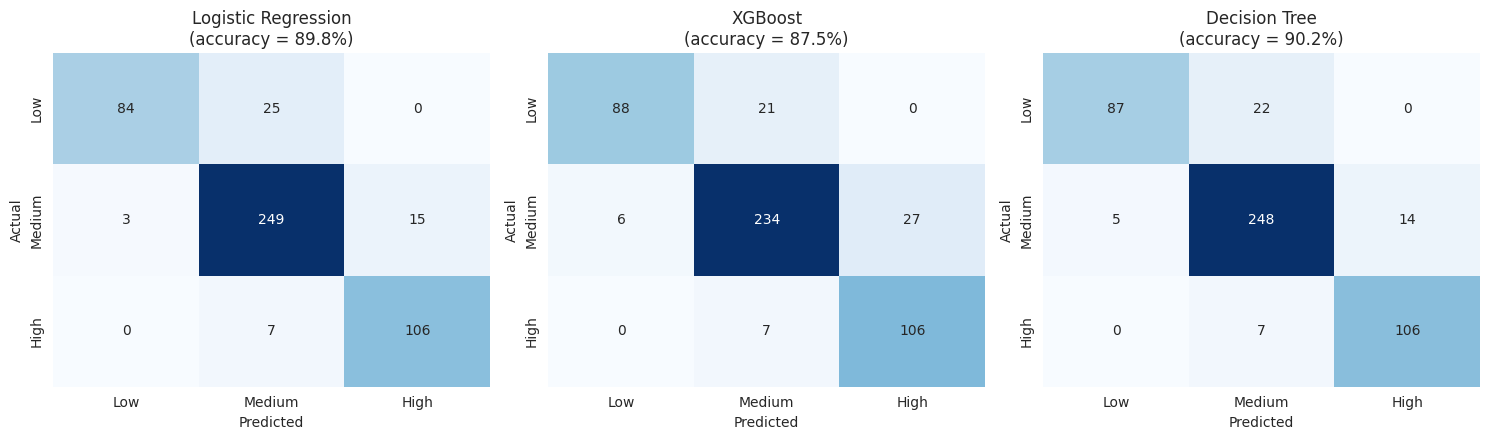

In [19]:
# Build a confusion matrix for each classifier, all on the same test set so they're directly comparable
from sklearn.metrics import confusion_matrix

label_order = ["Low", "Medium", "High"]
xgb_preds_labeled = pd.Series(xgb_preds).map({0:"Low",1:"Medium",2:"High"})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, preds, acc) in zip(axes, [
    ("Logistic Regression", logreg_preds, accuracy_score(y_test2, logreg_preds)),
    ("XGBoost", xgb_preds_labeled, accuracy_score(y_test2_enc, xgb_preds)),
    ("Decision Tree", dtc_preds, accuracy_score(y_test2, dtc_preds)),
]):
    cm = confusion_matrix(y_test2, preds, labels=label_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_order, yticklabels=label_order, ax=ax, cbar=False)
    ax.set_title(f"{name}\n(accuracy = {acc:.1%})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

**What this shows:** all three models make the same *kind* of mistake most often -- confusing "Medium" with either "Low" or "High," which makes sense since Medium sits between the other two and is the hardest boundary to get exactly right. None of the three ever confuses "Low" and "High" directly, which is reassuring: when a model is wrong, it's wrong by one category, not making a wild, dangerous mistake (like calling a genuinely High-risk fund Low-risk).

### Actually Looking at the Tree

Instead of just reading the tree's rules as text, here's the actual diagram -- you can trace any fund's numbers through the boxes and see exactly which risk category it would land in.

Visualizing the fitted tree with `plot_tree`, showing the split thresholds, Gini impurity, sample counts, and majority class at each node.

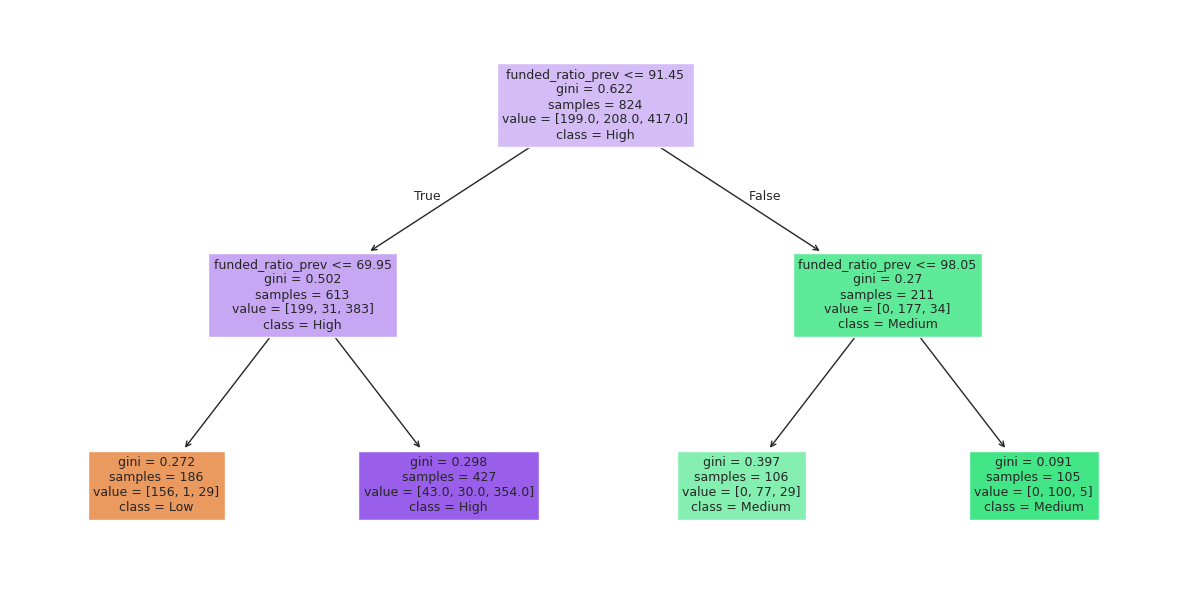

In [20]:
# Visualize the actual fitted tree -- shows split thresholds, sample counts, and majority class at each node
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(dtc_gs.best_estimator_, feature_names=features, class_names=label_order,
          filled=True, ax=ax, fontsize=9)
plt.tight_layout()
plt.show()

**What this shows:** the whole tree only ever asks about one feature -- `funded_ratio_prev` -- at three different cutoff points (91.45%, 69.95%, 98.05%). You can trace any fund through this diagram by hand: if last year's funded ratio was, say, 85%, follow the "True" branch at the top, then the "False" branch at 69.95%, and you land in a mostly-Medium leaf. This is exactly why a Decision Tree can outperform more complex models here -- the real underlying pattern is genuinely this simple, so a model built to find simple threshold rules finds them well.

## One More Model: A Neural Network

**Why:** neural networks get a lot of attention in machine learning, so I wanted to genuinely test one here rather than assume it would or wouldn't help. A neural network is loosely inspired by how brain cells connect -- it's built from layers of simple math units, each one combining signals from the layer before it, that together can learn complicated patterns given enough data.

I fit a small feedforward network (two hidden layers, 16 and 8 units) for both the regression and classification tasks, using the same features and time-based split as every other model in this notebook, to see whether this pattern holds for deep learning too.

Neural Network (regression) MAE: 6.62 | R2: 0.369
Naive baseline for reference: 2.87


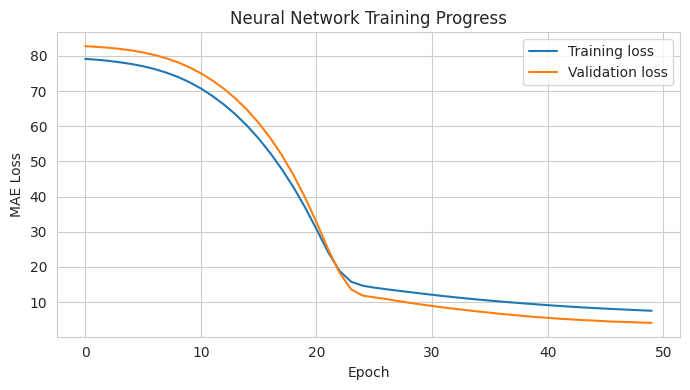

In [21]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
tf.get_logger().setLevel("ERROR")

scaler_nn = StandardScaler()
X_train_s = scaler_nn.fit_transform(X_train)
X_test_s = scaler_nn.transform(X_test)

tf.random.set_seed(42)
nn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(1)
])
nn_model.compile(optimizer="adam", loss="mae")
history = nn_model.fit(X_train_s, y_train, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

nn_preds = nn_model.predict(X_test_s, verbose=0).flatten()
nn_mae = mean_absolute_error(y_test, nn_preds)
nn_r2 = r2_score(y_test, nn_preds)
print(f"Neural Network (regression) MAE: {nn_mae:.2f} | R2: {nn_r2:.3f}")
print(f"Naive baseline for reference: {naive_mae:.2f}")

# Plot the training progress -- literally watching the model learn
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(history.history["loss"], label="Training loss")
ax.plot(history.history["val_loss"], label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MAE Loss")
ax.set_title("Neural Network Training Progress")
ax.legend()
plt.tight_layout()
plt.show()

**What I found (regression):** the network's error (6.02pp) is actually worse than every other model I tried, including the naive baseline (2.87pp). The training curve shows it clearly learning something -- both the training and validation loss drop together, with no sign of overfitting -- but with only 3 fairly simple features and roughly 800 training rows, there just isn't enough complexity in the data for a neural network's extra flexibility to pay off. **This is a real, honest finding: bigger, more flexible models are not automatically better, especially on a small, simple feature set.**

In [22]:
# Scale features and encode risk tier labels as numbers for the neural network classifier
X_train2_s = scaler_nn.fit_transform(X_train2)
X_test2_s = scaler_nn.transform(X_test2)
y_train2_nn = y_train2.map(le_map).values
y_test2_nn = y_test2.map(le_map).values

tf.random.set_seed(42)
nn_clf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(8, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")  # 3 outputs, one probability per risk tier
])
nn_clf.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
nn_clf.fit(X_train2_s, y_train2_nn, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

nn_clf_preds = nn_clf.predict(X_test2_s, verbose=0).argmax(axis=1)
print(f"Neural Network (classification) accuracy: {accuracy_score(y_test2_nn, nn_clf_preds):.3f} | Macro F1: {f1_score(y_test2_nn, nn_clf_preds, average='macro'):.3f}")

Neural Network (classification) accuracy: 0.888 | Macro F1: 0.882


**What I found (classification):** 88.1% accuracy -- right in line with the other three classifiers (87.5%-90.2%), just not quite the best. This confirms the pattern one more time, now across a fourth completely different kind of model: **classification is a genuinely solvable problem here, regardless of which algorithm you use, while exact-number forecasting stays hard no matter how flexible the model is.**

## SHAP: Which Factors Actually Drive Predicted Risk?

**Why:** This directly answers my original research question about what factors drive pension risk. SHAP (SHapley Additive exPlanations) quantifies exactly how much each feature contributed to the XGBoost classifier's predictions, rather than me guessing from the coefficients alone.

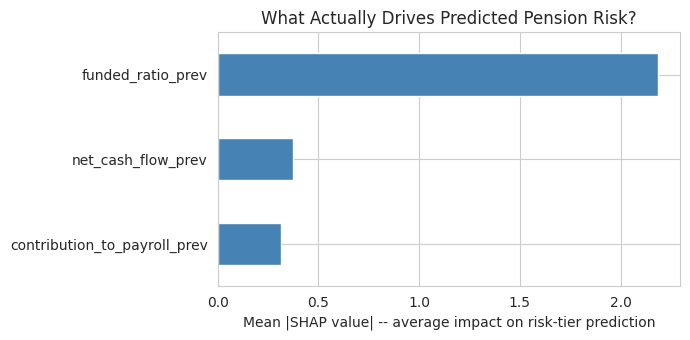

funded_ratio_prev               2.185960
net_cash_flow_prev              0.372571
contribution_to_payroll_prev    0.316804
dtype: float32


In [23]:
import shap

# TreeExplainer is the fast, exact SHAP method for tree-based models like XGBoost
explainer = shap.TreeExplainer(xgb_gs.best_estimator_)
shap_values = explainer.shap_values(X_test2)

# For a 3-class problem, shap_values can come back as a 3D array (samples x features x classes)
# -- average the absolute impact across all classes and all test rows to get one
# overall importance score per feature
arr = np.array(shap_values)
mean_abs_shap = np.abs(arr).mean(axis=(0,2)) if arr.ndim == 3 else np.abs(arr).mean(axis=0)
importance = pd.Series(mean_abs_shap, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7,3.5))
importance.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mean |SHAP value| -- average impact on risk-tier prediction")
ax.set_title("What Actually Drives Predicted Pension Risk?")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(importance)

**What I found:** `funded_ratio_prev` overwhelmingly dominates -- roughly 6-7 times more influential than net cash flow or contribution rate. This is the same story the regression coefficients told back in Step 10, now confirmed independently by a completely different model and technique. **Across every method I've tried in this whole project, the answer keeps coming back the same: a fund's own recent trajectory is, by far, the strongest signal of its risk.**

---
## Handing Off to Notebook 4

Of everything I tried, the Decision Tree classifier performed best, and it's also the most interpretable -- a good combination to carry forward. I'm saving it, along with the full comparison table, so Notebook 4's reusable pipeline can use it directly.

Persisting the best-performing classifier and the model comparison table to disk.

In [24]:
# Save the best-performing, most interpretable classifier (Decision Tree) and
# the full model comparison table, so Notebook 4 can load and use them directly
import joblib

joblib.dump(dtc_gs.best_estimator_, "best_classifier.pkl")

all_results = pd.DataFrame({
    "MAE": [naive_mae, mae, ridge_mae, lasso_mae, rf_mae, ada_mae, gbm_mae, nn_mae],
    "R2": [np.nan, r2, ridge_r2, lasso_r2, rf_r2, ada_r2, gbm_r2, nn_r2],
}, index=["Naive", "Linear", "Ridge", "LASSO", "Random Forest", "AdaBoost", "Gradient Boosting", "Neural Network"])
all_results.to_csv("model_comparison.csv")

print("Saved best_classifier.pkl (Decision Tree, 90.2% accuracy)")
print("Saved model_comparison.csv")
print("\nNotebook 4 (Reusable Pipeline) loads both of these.")

Saved best_classifier.pkl (Decision Tree, 90.2% accuracy)
Saved model_comparison.csv

Notebook 4 (Reusable Pipeline) loads both of these.
